In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv") #----- 자기 경로 설정!!
df_cleaned = pd.read_csv("first_clean_data.csv")

In [31]:
# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [32]:
df_machine = df_cleaned.copy()
df_machine.head()

,Unnamed: 0,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197


In [33]:
drop_cols = ['name', 'description', 'neighbourhood_cleansed', 'number_of_reviews', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication',
            'review_scores_location', 'review_scores_value','estimated_occupancy_l365d','estimated_revenue_l365d','calculated_host_listings_count_shared_rooms','reviews_per_month',
            'calculated_host_listings_count','calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms','host_id','host_since','id','latitude',
            'longitude','amenities','property_type','review_scores_accuracy']
df_machine=df_machine.drop(columns = drop_cols)
df_machine.shape


(22248, 15)

In [34]:
host_is_idx = df_machine.loc[df_machine['host_is_superhost'] == 'unknown'].index
df_machine = df_machine.drop(host_is_idx)

In [35]:
df_machine['host_is_superhost'].value_counts()

host_is_superhost
False    15746
True      6129
Name: count, dtype: int64

In [36]:
neighborhood_idx = df_machine.loc[df_machine['neighbourhood_group_cleansed'].isin(['Bronx','Staten Island'])].index
df_machine = df_machine.drop(neighborhood_idx)

In [37]:
df_machine['neighbourhood_group_cleansed'].value_counts()

neighbourhood_group_cleansed
Manhattan    10008
Brooklyn      7328
Queens        3325
Name: count, dtype: int64

In [38]:
room_idx = df_machine.loc[df_machine['room_type'].isin(['Hotel room','Shared room'])].index
df_machine = df_machine.drop(room_idx)

In [39]:
df_machine['room_type'].value_counts()

room_type
Entire home/apt    11868
Private room        8358
Name: count, dtype: int64

In [40]:
df_machine.shape

(20226, 15)

In [41]:
from sklearn.model_selection import train_test_split
# 타겟(y)에 NaN이 있는 행은 학습에서 제외 version 1
df_final = df_machine.dropna(subset=['price'])

X = df_final.drop(columns=["price"])
y = df_final["price"]
# X = df_machine.drop(columns=["review_scores_rating"])
# y = df_machine["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [42]:
#col = "review_scores_accuracy"
#X_train[f"{col}_isna"] = X_train[col].isna().astype(int)
#X_test[f"{col}_isna"]  = X_test[col].isna().astype(int)

In [43]:
# 2. 원 핫 인코딩
cat_cols = ["neighbourhood_group_cleansed", "room_type","host_is_superhost"]
X_train_dum = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_dum = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
# 3. reindex(=컬럼 정렬)
X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)

In [44]:
X_train_dum.columns

Index(['Unnamed: 0', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'accommodates', 'bedrooms', 'beds',
       'availability_365', 'number_of_reviews_ltm', 'review_scores_rating',
       'log_price', 'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens', 'room_type_Private room',
       'host_is_superhost_True'],
      dtype='str')

In [45]:
X_test_dum.columns

Index(['Unnamed: 0', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'accommodates', 'bedrooms', 'beds',
       'availability_365', 'number_of_reviews_ltm', 'review_scores_rating',
       'log_price', 'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Queens', 'room_type_Private room',
       'host_is_superhost_True'],
      dtype='str')

In [46]:
X_train_dum.info()

<class 'pandas.DataFrame'>
Index: 16180 entries, 1105 to 17504
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Unnamed: 0                              16180 non-null  int64  
 1   host_response_time                      16180 non-null  float64
 2   host_response_rate                      16180 non-null  float64
 3   host_acceptance_rate                    16180 non-null  float64
 4   accommodates                            16180 non-null  int64  
 5   bedrooms                                16180 non-null  float64
 6   beds                                    16180 non-null  float64
 7   availability_365                        16180 non-null  int64  
 8   number_of_reviews_ltm                   16180 non-null  int64  
 9   review_scores_rating                    11275 non-null  float64
 10  log_price                               16180 non-null  float64
 11  ne

In [47]:
# price는 극단값이 꽤 있어서 로그 변환을 같이 쓰는 경우가 많음
#X_train_dum["price_log1p"] = np.log1p(X_train_dum["price"])  # log(1+price)
#X_test_dum["price_log1p"] = np.log1p(X_test_dum["price"])

In [48]:
from sklearn.preprocessing import StandardScaler

scale_cols = ["host_response_time", "host_response_rate", "host_acceptance_rate","accommodates","bedrooms","beds","availability_365","number_of_reviews_ltm","review_scores_accuracy",
            "review_scores_accuracy_isna"] # "price_log1p", 
scale_cols = [c for c in scale_cols if c in X_train_dum.columns]  # 안전장치

scaler = StandardScaler()
X_train_dum[scale_cols] = scaler.fit_transform(X_train_dum[scale_cols])
X_test_dum[scale_cols] = scaler.transform(X_test_dum[scale_cols])

X_train_dum[scale_cols].describe()

,host_response_time,host_response_rate,host_acceptance_rate,accommodates,bedrooms,beds,availability_365,number_of_reviews_ltm
count,1.618000e+04,1.618000e+04,1.618000e+04,1.618000e+04,1.618000e+04,1.618000e+04,1.618000e+04,1.618000e+04
mean,4.259743e-17,-7.333785e-17,8.519486e-17,1.053957e-17,5.269785e-17,-2.151829e-17,-3.688850e-17,1.317446e-17
std,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00
min,-1.850183e+00,-1.836138e+00,-3.036059e+00,-9.424657e-01,-1.419897e+00,-1.378576e+00,-2.117460e+00,-2.319058e-01
25%,-2.912078e-01,-1.839302e-01,-2.744451e-01,-4.444060e-01,-3.351465e-01,-5.323618e-01,-7.911284e-01,-2.319058e-01
50%,7.481088e-01,6.178766e-01,3.008911e-01,-4.444060e-01,-3.351465e-01,-5.323618e-01,2.681562e-01,-2.319058e-01
75%,7.481088e-01,6.178766e-01,7.611601e-01,5.517135e-01,7.496044e-01,3.138524e-01,1.006985e+00,-1.209268e-01
max,7.481088e-01,6.178766e-01,7.995159e-01,6.528430e+00,1.485137e+01,3.416242e+01,1.131607e+00,6.576358e+01


In [49]:
# 중앙값으로 결측치를 채움 (isna 컬럼이 있으므로 정보 손실 걱정 없음)
#accuracy_median = X_train_dum['review_scores_accuracy'].median()

#X_train_dum['review_scores_accuracy'] = X_train_dum['review_scores_accuracy'].fillna(accuracy_median)
#X_test_dum['review_scores_accuracy'] = X_test_dum['review_scores_accuracy'].fillna(accuracy_median)

In [50]:
# 학습에 사용하지 않을 중복/불필요 컬럼 제거
cols_to_drop = ['Unnamed: 0']#'log_price',  
X_train_final = X_train_dum.drop(columns=[c for c in cols_to_drop if c in X_train_dum.columns])
X_test_final = X_test_dum.drop(columns=[c for c in cols_to_drop if c in X_test_dum.columns])

In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 학습에 사용할 수치형 변수와 범주형 변수 정의
target = "price_log1p"

# 수치형 변수 리스트 (스케일링 대상)
scale_cols = [
    "price_log1p", "host_response_time", "host_response_rate", "host_acceptance_rate",
    "accommodates", "bedrooms", "beds", "availability_365", "number_of_reviews_ltm"]

    #"review_scores_accuracy"
#]

# 범주형 변수 리스트 (원-핫 인코딩 대상)
cat_cols = ["neighbourhood_group", "room_type"]

# 데이터 정제 (문자열 에러 방지)
# X_train에서 실제로 존재하는 컬럼만 남기고, ID나 Name 같은 텍스트는 제외합니다.
existing_cols = [c for c in scale_cols + cat_cols if c in X_train.columns]
X_train_filtered = X_train[existing_cols].copy()
X_test_filtered = X_test[existing_cols].copy()

# 원-핫 인코딩 & 컬럼 맞추기
# 실제 cat_cols가 존재할 때만 인코딩 수행
X_train_dum = pd.get_dummies(X_train_filtered, columns=[c for c in cat_cols if c in X_train_filtered.columns], drop_first=True)
X_test_dum = pd.get_dummies(X_test_filtered, columns=[c for c in cat_cols if c in X_test_filtered.columns], drop_first=True)

# Train 기준 컬럼 동기화 (reindex)
X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)

# 결측치 처리
# 이미 전단계에서 정제를 마쳤으나, 
# 신규데이터에서 기입할 수 있는 결측치에 대비한 안전장치가 필요함
numeric_cols = X_train_dum.select_dtypes(include=[np.number]).columns
train_median = X_train_dum[numeric_cols].median() # 학습 데이터의 기준값 보관

X_train_dum[numeric_cols] = X_train_dum[numeric_cols].fillna(train_median)
X_test_dum[numeric_cols] = X_test_dum[numeric_cols].fillna(train_median) # 학습 데이터 기준 적용

# 스케일링
# scale_cols 중 실제 존재하는 것만 스케일링
final_scale_target = [c for c in scale_cols if c in X_train_dum.columns]
scaler = StandardScaler()
X_train_dum[final_scale_target] = scaler.fit_transform(X_train_dum[final_scale_target])
X_test_dum[final_scale_target] = scaler.transform(X_test_dum[final_scale_target])

# 모델 학습 및 평가
# --- 로그 변환 추가 구간 ---
# y값(가격)에 로그를 씌웁니다. 0이 있을 수 있으므로 log1p를 사용합니다.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
# -----------------------

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 학습은 로그를 씌운 값(y_train_log)으로 진행합니다.
model.fit(X_train_dum, y_train_log)

# 예측 결과도 로그 형태입니다.
y_train_pred_log = model.predict(X_train_dum)
y_test_pred_log = model.predict(X_test_dum)

# 다시 실제 달러($) 가격으로 복원합니다 (expm1)
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

# 결과 출력 (이후 코드는 동일)
print(f"Train R2: {r2_score(y_train, y_train_pred):.4f} | Test R2: {r2_score(y_test, y_test_pred):.4f}")

print(f"Train R2: {r2_score(y_train, y_train_pred):.4f} | Test R2: {r2_score(y_test, y_test_pred):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.4f} | Test MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

Train R2: 0.5196 | Test R2: 0.1355
Train R2: 0.5196 | Test R2: 0.1355
Train MAE: 46.8260 | Test MAE: 88.3707


In [52]:
from sklearn.metrics import r2_score, mean_absolute_error

y_train_pred = model.predict(X_train_dum)

y_test_pred = model.predict(X_test_dum)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

Train R2: -0.2450093945973606
Test R2: -0.1903746254873342
Train MAE: 208.87044636746282
Test MAE: 210.08707871673394


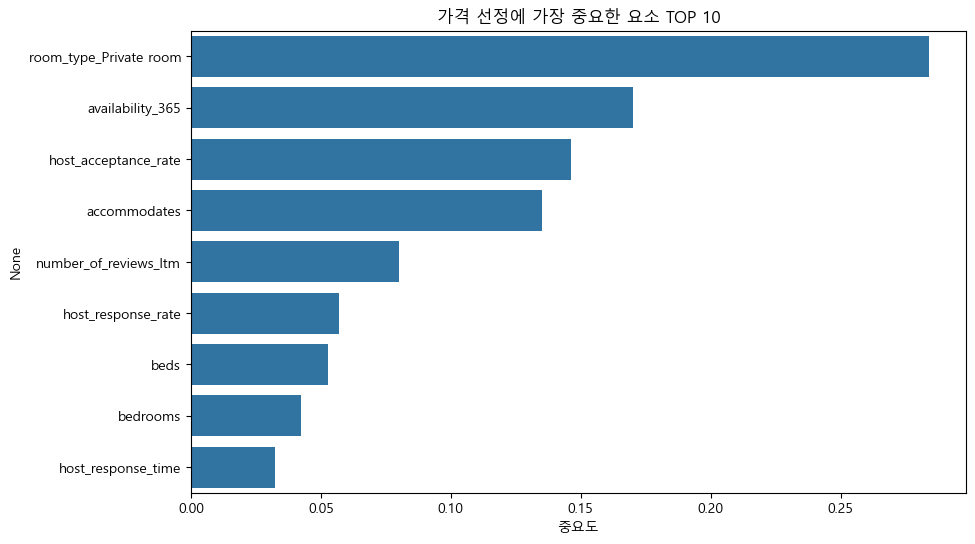

In [53]:
# 변수 중요도 추출
importances = model.feature_importances_

feature_names = X_train_dum.columns 

feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(10), y=feature_importances.head(10).index)
plt.title("가격 선정에 가장 중요한 요소 TOP 10")
plt.xlabel("중요도")
plt.show()

In [54]:
# 신규 호스트 가상 데이터 (딕셔너리)
my_listing = {
    #'price': 1000, 
    'host_response_time': 1,
    'host_response_rate': 100,
    'host_acceptance_rate': 95,
    'accommodates': 2,
    'bedrooms': 1,
    'beds': 2,
    'availability_365': 200,
    'number_of_reviews_ltm': 10,
    'review_scores_accuracy': 5.0,
    'neighbourhood_group': 'Manhattan', 
    'room_type': 'Entire home/apt'
}

# 예측 함수 (첫 번째 코드의 전처리 방식을 그대로 따름)
def predict_with_refined_model(input_data):
    test_df = pd.DataFrame([input_data])
    
    # 로그 변환
    if 'price' in test_df.columns:
        test_df['price_log1p'] = np.log1p(test_df['price'])
    
    # 원-핫 인코딩 및 컬럼 맞추기
    # 첫 번째 코드의 X_train_dum 컬럼들을 0으로 초기화한 뒤 매핑
    final_input = pd.DataFrame(0, index=[0], columns=X_train_dum.columns)
    
    for col, value in test_df.iloc[0].items():
        if col in final_input.columns:
            final_input[col] = value
        else:
            combined_col = f"{col}_{value}"
            if combined_col in final_input.columns:
                final_input[combined_col] = 1
    
    # 스케일링 (첫 번째 코드에서 만든 scaler 사용)
    # final_scale_target 리스트를 재사용
    final_input[final_scale_target] = scaler.transform(final_input[final_scale_target])
    
    # 예측
    prediction = model.predict(final_input)[0]
    return prediction

# 결과 출력
score = predict_with_refined_model(my_listing)
print(f"예상 가격: {score:.2f}")

예상 가격: 4.99


## 1차 문제점 : 전처리 시간에 배운 지도 학습 모델 LogisticRegression는 분류를 예측하는 모델로써 우리 팀의 목표 : 평점은 <랜덤 포레스트 회귀> 또는 <XGboost> 모델을 활용해야 함 이건 궁금하신 분 계시면 말씀드릴께요 
## 2차 문제점 : 예상 모델 점수가 엄청 높은 편은 아님 <br>모델의 검증 방법 더 찾아볼 필요 O <br>(그렇다고 엄청 낮은것도 아니래요)<br>검증 방법 중 가장 유명한걸 사용하려면(교차 검증) 모든컬럼이 수치형일 필요가 있어서 이건 튜터님께 여쭤보는 것도 좋은듯..앞에 1차 문제 다같이 이해하면요
## 3차 문제점 : 가격이 올라가면 ?<br>예상 평점이 높아져요 추가적인 인사이트 필요한데 <br> 원인은 주어진 데이터만 가지고는 예를들어 맨하탄 지역에서 가격이 높은 숙소 일반적으로 럭셔리 할거라 평점이 높아집니다 그런데 이를 해결하기 위해선 주어진 리소스가 한정적인 상황(200에서 키랑 몸무게 배분하기 같은거...)에 추가적으로 현실적인 문제를 데이터가 보고 반영 할 수 있는 가격제한이 있거나, 수용 인원 별 가격, 지역별 가격의 파생컬럼 등등 뭔가가 필요해요 <br> 
## 4차 문제점 : 로그변환한 가격 때문에 모델의 정확도 로지스틱 회귀(분류)에서의 정확도에 해당하는 랜덤 포레스트 회귀(회귀)에서의 R2 Score(결정계수) 지표가 떨어져요 (오차범위를 알려주는 MAE라는 지표도 회귀 예측 모델에 존재한다고 하네요) 그렇지만 가격이 바뀌었을 때 예상평점이 팍팍 바뀌려는걸 보고싶으면 모델의 정확도가 낮아 지더라도 가격의 스케일링은 다시 원상복귀 해야 할 가능성이 있네요
## 5차 문제점 : 2차, 4차 문제점을 합쳐서 정확도를 올리는 방법이 존재 하는데 이는 랜덤 포레스트 회귀 모델에서는 나무 깊이, 나무 개수 늘리기, 교차 검증(모든 컬럼의 데이터가 수치형이여야 함) 등 존재 튜터님께 여쭤보면서 배우면 좋을거 같아요
## 6차 문제점 : 표로 만들어 봤는데 역시나 압도적인 1위는 정확성 평점이에요 이거 바꾸고 싶으실 수 있는데 빼도 되는지 안되는지는 판단이 어렵네요